In [1]:
import sys
print(sys.executable)

/Users/jannoelvero/Documents/Ironhack/week_5/day_2/lab-eda-bivariate/.venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy import stats

In [3]:
df = pd.read_csv("data/amz_uk_price_prediction_dataset.csv")

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.shape

(2443651, 9)

In [6]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [8]:
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [9]:
###Part 1: Analyzing Best-Seller Trends Across Product Categories

In [10]:
# Crosstab Analysis:
# Calculate the proportion of best sellers within each categor
best_seller_crosstab = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

best_seller_crosstab.head(10)

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
Agricultural Equipment & Supplies,8421,109
Alexa Built-In Devices,106,1
Art & Craft Supplies,253,5
Arts & Crafts,9319,230


In [11]:
#sort the categories by their proportion of best sellers:
best_seller_proportion = pd.crosstab(
    df["category"],
    df["isBestSeller"],
    normalize="index"
)

best_seller_proportion.head(10)

isBestSeller,False,True
category,,
3D Printers,0.995968,0.004032
3D Printing & Scanning,0.999508,0.000492
Abrasive & Finishing Products,0.980000,0.020000
Action Cameras,0.999411,0.000589
Adapters,0.988189,0.011811
Agricultural Equipment & Supplies,0.987222,0.012778
Alexa Built-In Devices,0.990654,0.009346
Art & Craft Supplies,0.980620,0.019380
Arts & Crafts,0.975914,0.024086


In [12]:
# Sort by best seller proportion
best_seller_proportion = best_seller_proportion.sort_values(
    by=True,
    ascending=False
)

best_seller_proportion.head(10)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
"Billiard, Snooker & Pool",0.967871,0.032129
Pet Supplies,0.969800,0.030200
Home Brewing & Wine Making,0.971545,0.028455
Wind Instruments,0.972000,0.028000


In [13]:
# Statistical Tests:

# Chi Square Test
chi2, p_value, dof, expected = chi2_contingency(best_seller_crosstab)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 36540.20270061387
P-value: 0.0
Degrees of freedom: 295


In [14]:
# The Chi square test produced a p value below 0.05. Therefore, we reject the null hypothesis that product category and best seller status are independent. This indicates that there is a statistically significant association between product category and best seller status.

In [15]:
# Cramér's V
n = best_seller_crosstab.to_numpy().sum()
min_dim = min(best_seller_crosstab.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


In [16]:
# Cramér's V is approximately 0.122, indicating a weak association between product category and best seller status. Although the Chi square test found a statistically significant relationship, Cramér's V shows that the strength of this relationship is relatively weak.

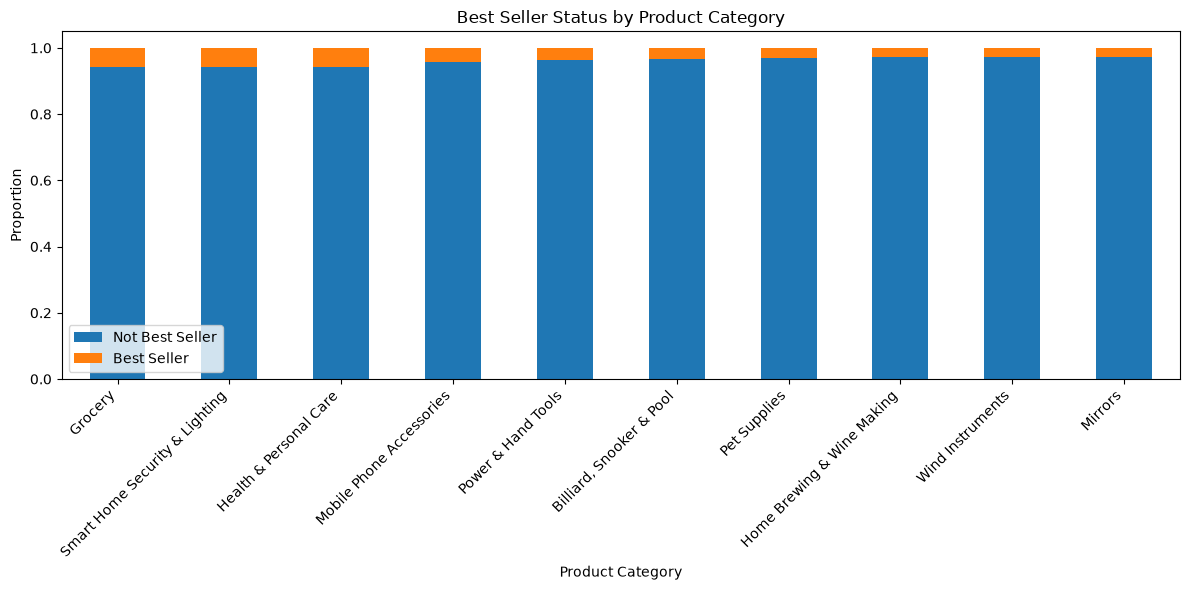

In [17]:
# Visualizations:
top_10_categories = best_seller_proportion.head(10)

top_10_categories.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Best Seller Status by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(["Not Best Seller", "Best Seller"])
plt.tight_layout()
plt.show()

In [18]:
# Findings
# Best seller status varies across Amazon UK product categories. Grocery has the highest proportion of best sellers at approximately 5.81 percent, followed by Smart Home Security and Lighting at 5.77 percent and Health and Personal Care at 5.77 percent. The Chi square test produced a p value below 0.05, indicating that product category and best seller status are statistically associated. However, Cramér's V was approximately 0.122, which suggests that the strength of this association is weak. The stacked bar chart supports this result, showing that best sellers represent only a small proportion of products even within the categories with the highest best seller prevalence.

In [19]:
#Business Interpretation: Product category appears to influence the likelihood of a product becoming a best seller, but category alone is not a strong predictor. Businesses should therefore consider other factors such as pricing, ratings, reviews, demand, and product visibility when evaluating best seller potential.

In [20]:
###Part 2: Exploring Product Prices and Ratings Across Categories and Brands


In [21]:
#Preliminary Step: Remove outliers in product prices.
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 9.99
Q3: 45.99
IQR: 36.0
Lower bound: -44.01
Upper bound: 99.99000000000001


In [22]:
# Create the dataframe without outliers
df_no_outliers = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

df_no_outliers.shape

(2115963, 9)

In [23]:
#how many products were removed
removed_products = len(df) - len(df_no_outliers)

print("Original products:", len(df))
print("Products after removing outliers:", len(df_no_outliers))
print("Products removed:", removed_products)

Original products: 2443651
Products after removing outliers: 2115963
Products removed: 327688


In [24]:
#percentage
removed_percentage = (removed_products / len(df)) * 100

print("Percentage removed:", round(removed_percentage, 2), "%")

Percentage removed: 13.41 %


In [25]:
#Using the IQR method, product prices above approximately £99.99 were identified as outliers. A total of 327,688 products were removed, representing 13.41 percent of the original dataset. The remaining 2,115,963 products will be used for the main analysis.

In [26]:
#Violin Plots:
top_20_categories = df_no_outliers["category"].value_counts().head(20).index

top_20_categories
df_top_20 = df_no_outliers[
    df_no_outliers["category"].isin(top_20_categories)
].copy()

df_top_20.shape

(1033008, 9)

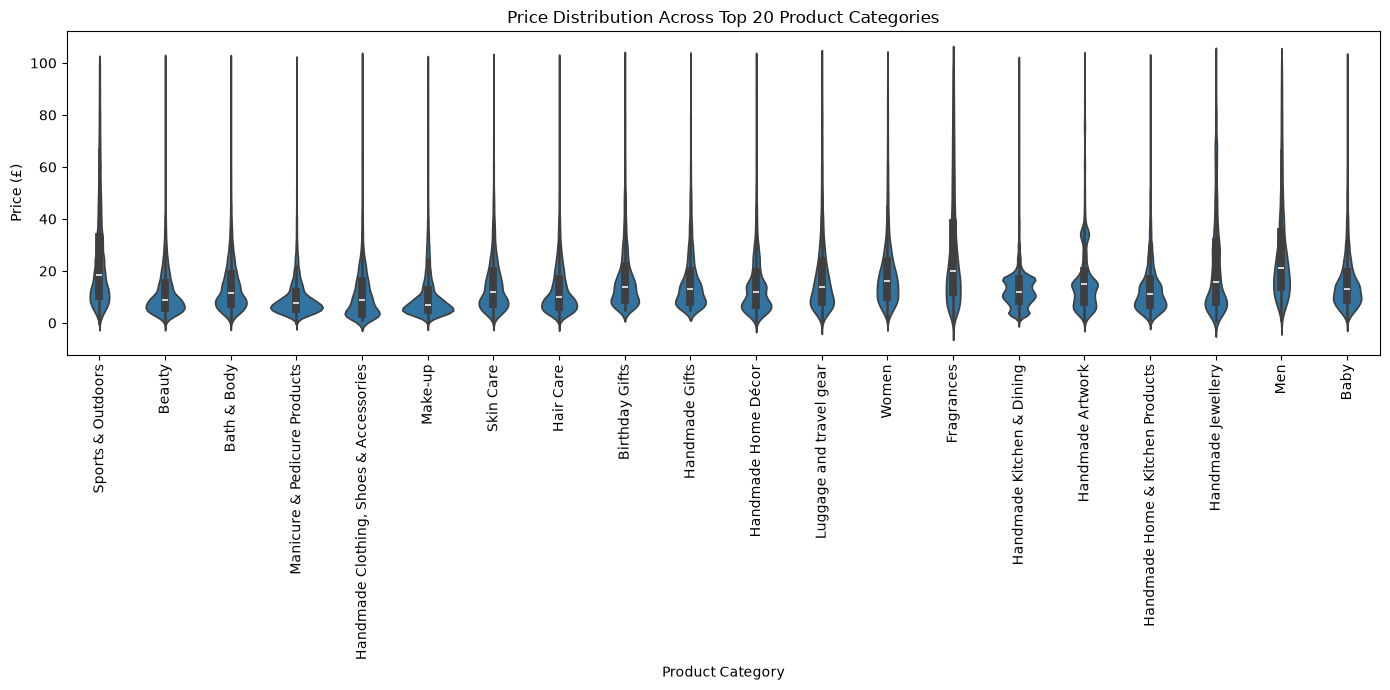

In [27]:
top_20_categories = df_no_outliers["category"].value_counts().head(20).index

df_top_20 = df_no_outliers[
    df_no_outliers["category"].isin(top_20_categories)
].copy()

plt.figure(figsize=(14, 7))

sns.violinplot(
    data=df_top_20,
    x="category",
    y="price",
    order=top_20_categories
)

plt.title("Price Distribution Across Top 20 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Price (£)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [28]:
median_price_by_category = (
    df_no_outliers.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

median_price_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

In [29]:
df_top_20

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
19513,21072,B09477KHQ3,"Personalised Birthday Print Gift ""THE YEAR YOU...",4.5,763,7.99,False,900,Handmade Home & Kitchen Products
19514,21073,B0BSRFQYG8,Wax Melts 4 Bars | Build Your Own Box (Choose ...,3.9,117,6.49,True,800,Handmade Home & Kitchen Products
19515,21074,B09N9GVHV9,"Personalised Birthday Print Gift ""ON THE DAY/Y...",4.6,1155,8.99,True,600,Handmade Home & Kitchen Products
19516,21075,B0BRYGV7PQ,Fresh Wax Melts - Laundry Type Wax Melts - Str...,4.5,56,4.99,True,500,Handmade Home & Kitchen Products
19517,21076,B0B1JHB28R,Manta Makes Work Leaving Gifts | I Used to Wor...,4.7,261,9.95,True,400,Handmade Home & Kitchen Products
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


In [30]:
df_no_outliers

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [31]:
median_price_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

In [32]:
#Interpretation: Desktop PCs have the highest median product price at £74.00, followed by Boxing Shoes at £69.79 and Tablets at £69.00. This indicates that Desktop PCs tend to have higher typical prices compared with other product categories after price outliers are removed.

In [33]:
#Bar Charts:
top_10_categories = df_no_outliers["category"].value_counts().head(10).index

top_10_categories
df_top_10 = df_no_outliers[
    df_no_outliers["category"].isin(top_10_categories)
].copy()
average_price_top_10 = (
    df_top_10.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

average_price_top_10

,category,price
0,Sports & Outdoors,25.172065
1,Birthday Gifts,18.600195
2,Handmade Gifts,17.395112
3,Skin Care,15.654722
4,Bath & Body,14.678683
5,Hair Care,13.461408
6,"Handmade Clothing, Shoes & Accessories",12.958639
7,Beauty,12.523480
8,Make-up,10.612918
9,Manicure & Pedicure Products,10.231825


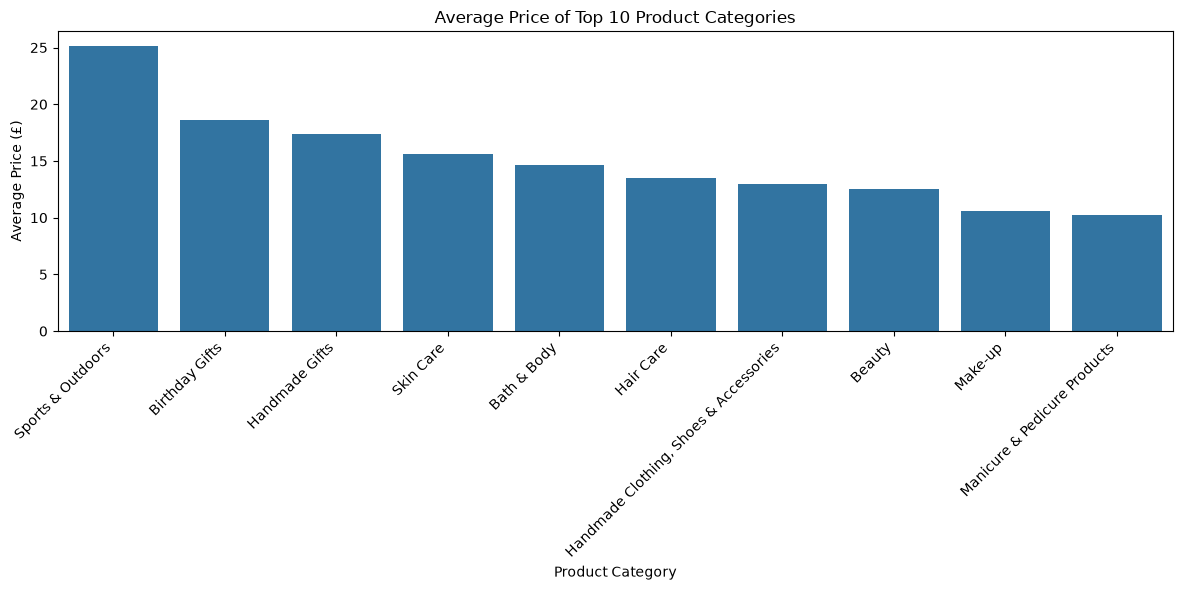

In [34]:
top_10_categories = df_no_outliers["category"].value_counts().head(10).index

df_top_10 = df_no_outliers[
    df_no_outliers["category"].isin(top_10_categories)
].copy()

average_price_top_10 = (
    df_top_10.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=average_price_top_10,
    x="category",
    y="price",
    order=average_price_top_10["category"]
)

plt.title("Average Price of Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
average_price_by_category = (
    df_no_outliers.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_category.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

In [36]:
#Interpretation: Motherboards command the highest average product price at approximately £68.77, followed by Boxing Shoes at £67.42 and Desktop PCs at £66.92. This indicates that Motherboards have the highest average price across all product categories after price outliers are removed.

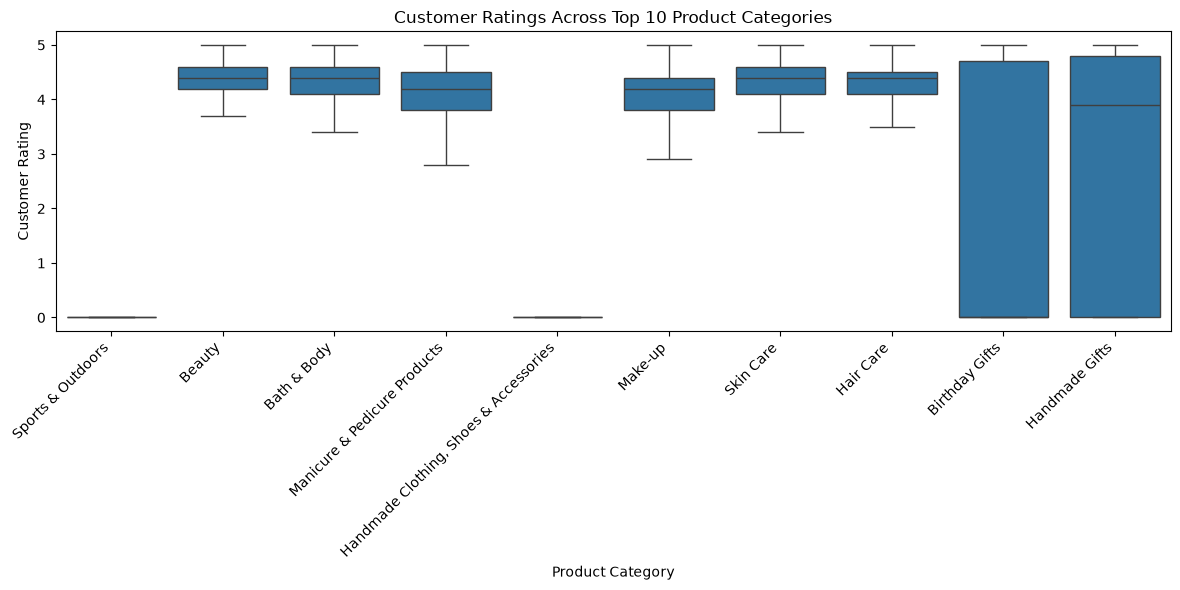

In [37]:
#Box Plot:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_10,
    x="category",
    y="stars",
    order=top_10_categories,
    showfliers=False
)

plt.title("Customer Ratings Across Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [38]:
median_rating_by_category = (
    df_no_outliers.groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

median_rating_by_category.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

In [39]:
#Interpretation: Computer Memory has the highest median customer rating at 4.7 stars. Several other categories have median ratings of 4.6 stars, indicating generally high customer satisfaction across these product groups.

In [40]:
#Findings: After applying the IQR method, 327,688 products were identified as price outliers and removed, representing 13.41 percent of the original dataset. The analysis of the remaining 2,115,963 products shows clear differences in pricing across product categories.

#Desktop PCs have the highest median price at £74.00, followed by Boxing Shoes at £69.79 and Tablets at £69.00. When average prices are considered, Motherboards rank highest at approximately £68.77, followed by Boxing Shoes at £67.42 and Desktop PCs at £66.92.

#Customer ratings also vary across categories. Computer Memory has the highest median rating at 4.7 stars, while several other categories have median ratings of 4.6 stars.

#Business Interpretation: Product category is an important consideration in both pricing and customer satisfaction. Technology related categories such as Desktop PCs, Motherboards, Tablets, and Graphics Cards tend to appear among the higher priced categories. However, a higher product price does not automatically correspond to the highest customer rating. Businesses should therefore evaluate pricing and customer satisfaction separately when developing category strategies.

In [41]:
###Part 3: Investigating the Interplay Between Product Prices and Ratings

In [42]:
#Correlation Coefficients:
correlation = df_no_outliers["price"].corr(df_no_outliers["stars"])

print("Correlation between price and stars:", correlation)

Correlation between price and stars: -0.07767299878181001


In [43]:
correlation, p_value = pearsonr(
    df_no_outliers["price"],
    df_no_outliers["stars"]
)

print("Pearson correlation:", correlation)
print("P-value:", p_value)

Pearson correlation: -0.0776729987818134
P-value: 0.0


In [44]:
#Interpretation: The Pearson correlation coefficient is approximately negative 0.078, indicating a very weak negative relationship between product price and customer rating. The p value is below 0.05, so the relationship is statistically significant. However, the correlation is very close to zero, which means product price has very little practical relationship with customer ratings.

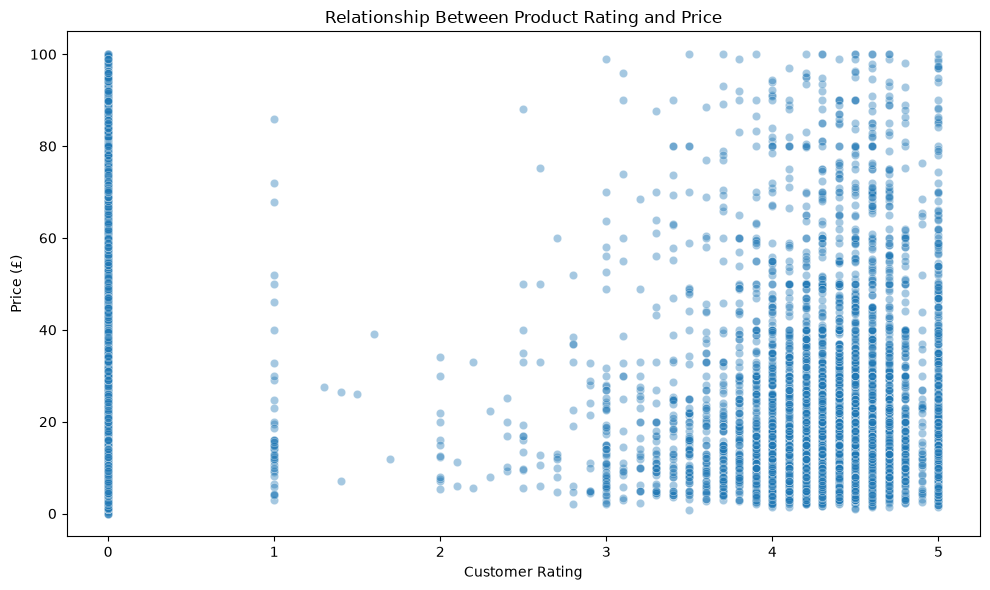

In [45]:
#Visualizations:
#Scatter Plot

plot_sample = df_no_outliers.sample(
    n=10000,
    random_state=42
)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="stars",
    y="price",
    alpha=0.4
)

plt.title("Relationship Between Product Rating and Price")
plt.xlabel("Customer Rating")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

In [46]:
#Scatter Plot Interpretation: The scatter plot shows a wide spread of product prices across different customer ratings, with no clear linear pattern. This supports the Pearson correlation result of negative 0.078, indicating that product price and customer rating have a very weak relationship.

In [47]:
#Correlation Heatmap
numeric_columns = [
    "stars",
    "reviews",
    "price",
    "boughtInLastMonth"
]

correlation_matrix = df_no_outliers[numeric_columns].corr()

correlation_matrix

,stars,reviews,price,boughtInLastMonth
stars,1.000000,0.083920,-0.077673,0.113994
reviews,0.083920,1.000000,-0.008498,0.105624
price,-0.077673,-0.008498,1.000000,-0.059051
boughtInLastMonth,0.113994,0.105624,-0.059051,1.000000


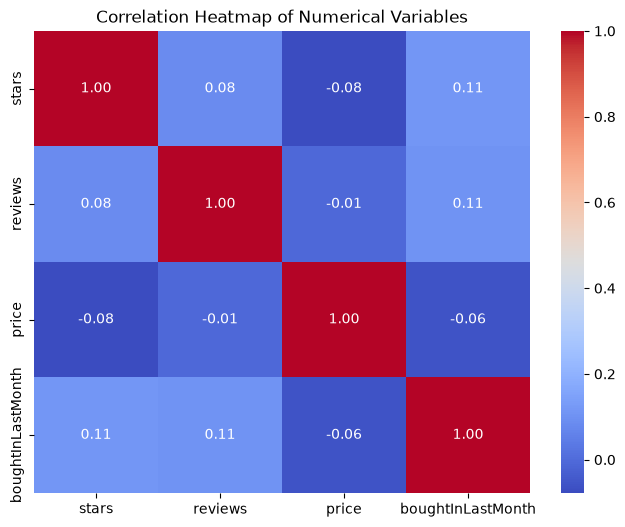

In [48]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [49]:
#Interpretation: The correlation heatmap shows generally weak relationships among the numerical variables. The strongest relationship is between customer rating and products bought in the last month at approximately 0.114, which is still very weak. Ratings and reviews have a weak positive correlation of 0.084, while price and rating have a weak negative correlation of negative 0.078. Overall, no strong linear relationships are observed among the numerical variables.

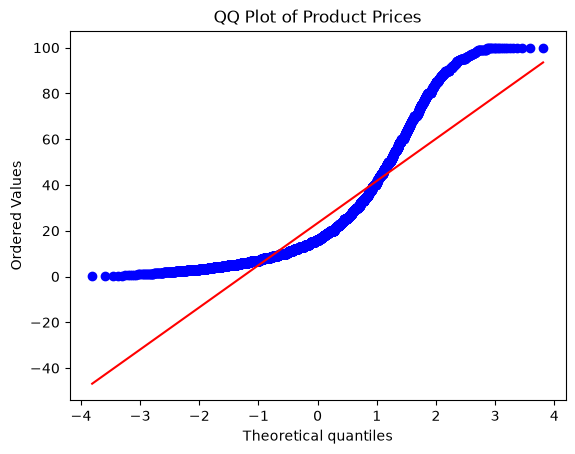

In [50]:
#QQ Plot
stats.probplot(
    plot_sample["price"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Product Prices")
plt.show()

In [51]:
#QQ Plot Interpretation: The points deviate substantially from the diagonal reference line, indicating that product prices do not follow a normal distribution. The curved pattern shows that the observed price distribution differs considerably from what would be expected under a normal distribution, even after removing price outliers.

In [52]:
#Findings: Product price and customer rating have a statistically significant but very weak negative correlation of approximately negative 0.078. This indicates that higher priced products do not necessarily receive higher customer ratings. The scatter plot supports this finding, showing no clear linear relationship between price and rating.

#The correlation heatmap also shows that the numerical variables have generally weak relationships with one another. The strongest observed correlation is between customer rating and products bought in the last month at approximately 0.114, which is still weak. Finally, the QQ plot shows substantial deviation from the reference line, indicating that product prices are not normally distributed.

#Business Interpretation: Price alone does not appear to be a strong indicator of customer satisfaction or recent purchasing activity. Businesses should therefore avoid assuming that higher prices will result in better customer ratings and should consider other factors such as product quality, category, customer reviews, and demand when developing pricing strategies.

In [53]:
#Bonus: Analysis With Price Outliers
correlation_with_outliers, p_value_with_outliers = pearsonr(
    df["price"],
    df["stars"]
)

print("Pearson correlation with outliers:", correlation_with_outliers)
print("P-value:", p_value_with_outliers)

Pearson correlation with outliers: -0.12490673262148619
P-value: 0.0


In [54]:
print("Without outliers:", correlation)
print("With outliers:", correlation_with_outliers)

Without outliers: -0.0776729987818134
With outliers: -0.12490673262148619


In [55]:
print("Average price with outliers:", round(df["price"].mean(), 2))
print("Average price without outliers:", round(df_no_outliers["price"].mean(), 2))

Average price with outliers: 89.24
Average price without outliers: 23.41


In [56]:
print("Median price with outliers:", round(df["price"].median(), 2))
print("Median price without outliers:", round(df_no_outliers["price"].median(), 2))

Median price with outliers: 19.09
Median price without outliers: 15.99


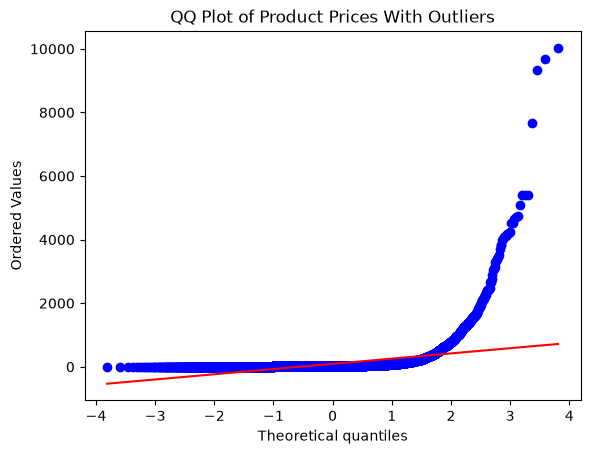

In [57]:
plot_sample_with_outliers = df.sample(
    n=10000,
    random_state=42
)

stats.probplot(
    plot_sample_with_outliers["price"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Product Prices With Outliers")
plt.show()

In [58]:
#Findings: Including price outliers changes the results of the analysis considerably. The Pearson correlation between price and customer rating changes from approximately negative 0.078 without outliers to negative 0.125 with outliers. Although both relationships are statistically significant, the correlation remains weak. The presence of extreme prices therefore increases the apparent negative relationship between price and customer rating.

#Price outliers have a particularly strong effect on the average product price. The mean price increases from £23.41 without outliers to £89.24 when outliers are included. In comparison, the median increases only from £15.99 to £19.09. This large difference between the effect on the mean and median demonstrates that extreme prices strongly influence the average while having a much smaller effect on the median.

#Business Interpretation: Extreme product prices can substantially distort pricing statistics, particularly the mean. For understanding the typical price of products on Amazon UK, the analysis without extreme price outliers provides a more representative view of the majority of products. The median is also more robust than the mean when extreme prices are present. Businesses should therefore consider the distribution of prices and the influence of extreme values before using average price as a benchmark.

In [59]:
#Final Business Findings

#The analysis of more than 2.4 million Amazon UK products shows that product category is associated with best seller status, but the relationship is weak. Grocery had the highest best seller proportion at approximately 5.81 percent, followed closely by Smart Home Security and Lighting and Health and Personal Care at approximately 5.77 percent. Although the Chi square test showed a statistically significant relationship, Cramér's V of approximately 0.122 indicates that category alone is not a strong predictor of best seller status.

#Product pricing also differs considerably across categories. After removing price outliers using the IQR method, Desktop PCs had the highest median price at £74.00, while Motherboards had the highest average price at approximately £68.77. Computer Memory recorded the highest median customer rating at 4.7 stars.

#The relationship between product price and customer rating was statistically significant but very weak, with a Pearson correlation of approximately negative 0.078. The scatter plot and correlation heatmap support this result, showing that price has little practical relationship with ratings, reviews, or recent purchases.

#The QQ plot showed that product prices do not follow a normal distribution, even after price outliers were removed. This means summary measures such as the mean should be interpreted carefully when describing typical product prices.

#The bonus analysis demonstrated the effect of outliers clearly. Including outliers increased the average product price from £23.41 to £89.24, while the median increased only from £15.99 to £19.09. The correlation between price and customer rating also changed from approximately negative 0.078 without outliers to negative 0.125 with outliers, although the relationship remained weak in both cases.

#Business Conclusion: Product category provides useful context for pricing and best seller performance, but it should not be considered in isolation. Higher prices do not necessarily lead to higher customer ratings, and extreme prices can substantially distort average price measures. Businesses should therefore evaluate category, pricing, ratings, reviews, and demand together when making product and marketplace decisions.